# Importing libraries and df

In [1]:
import pandas as pd
import numpy as np
from data_profiling import ProfileReport 
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 30)
%matplotlib inline

plt.style.use('default')

In [2]:
df = pd.read_csv('Airbnb_Open_Data.csv')

/var/folders/9m/d92m8dks0fb4fq5pygy1wsq40000gp/T/ipykernel_14897/2167922700.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Airbnb_Open_Data.csv')


In [3]:
#profile = ProfileReport(df, title = 'Airbnb_Profile_Report', explorative=True)
#profile.to_file('report.html')

# EDA

In [4]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [5]:
print(df.shape)

df.dtypes

(102599, 26)


id                                  int64
NAME                               object
host id                             int64
host_identity_verified             object
host name                          object
neighbourhood group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country code                       object
instant_bookable                   object
cancellation_policy                object
room type                          object
Construction year                 float64
price                              object
service fee                        object
minimum nights                    float64
number of reviews                 float64
last review                        object
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

## Column labels standardization and copy of original df for cleaning comparison 

In [6]:
df.columns = (df.columns
              .str.replace(' ', '_')
              .str.lower()
              .str.strip()
)

df_before_cleaning = df.copy()

df.head()

,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


## Dropping Duplicates

In [7]:
n_dupes = df.duplicated().sum()
print(n_dupes)

df[df.duplicated(keep = False)].sort_values(by=list(df.columns)).head(5)

df = df.drop_duplicates()

print(df.shape)

541
(102058, 26)


## Correcting data type to price, service fee, and last review

In [8]:
df['price'] = df['price'].str.replace(r'[$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df['service_fee'] = df['service_fee'].str.replace(r'[$,]', '', regex=True)
df['service_fee'] = pd.to_numeric(df['service_fee'], errors='coerce')

df['last_review'] = pd.to_datetime(df['last_review'], format = '%m/%d/%Y', errors = 'coerce')

print(df[['price', 'service_fee', 'last_review']].dtypes)


price                 float64
service_fee           float64
last_review    datetime64[ns]
dtype: object


## Missing values 

In [9]:
columns = df.columns.to_list()

missing_data = []

for col in columns:
    if df[col].isnull().sum() > 0:
        missing_data.append({
            'column': col,
            'Missing %': f'{df[col].isnull().mean()*100:.2}%',
            'dtype': df[col].dtypes
        })

missing_df = pd.DataFrame(missing_data)
missing_df

,column,Missing %,dtype
0,name,0.24%,object
1,host_identity_verified,0.28%,object
2,host_name,0.4%,object
3,neighbourhood_group,0.028%,object
4,neighbourhood,0.016%,object
5,lat,0.0078%,float64
6,long,0.0078%,float64
7,country,0.52%,object
8,country_code,0.13%,object
9,instant_bookable,0.1%,object


### Dropping license as it is completely empty

In [10]:
df = df.drop(columns=['license'])

### Identifying Object dtypes columns with missing values

In [11]:
missing_obj = df.select_dtypes(include = 'object').isnull().sum()

missing_obj[missing_obj > 0]

name                        250
host_identity_verified      289
host_name                   404
neighbourhood_group          29
neighbourhood                16
country                     532
country_code                131
instant_bookable            105
cancellation_policy          76
house_rules               51842
dtype: int64

### Filling NAs in Country and Country_Code with United States and US respectively as this is NYC open data. 

In [12]:
df = df.copy()

df['country'] = df['country'].fillna('United States')

df['country_code'] = df['country_code'].fillna('US')


### Replacing all NAn in object variables with 'Unknown'

In [13]:
missing_obj = missing_obj[missing_obj>0].index.to_list()
df[missing_obj] = df[missing_obj].fillna('Unknown')

### Dropping low missing % for numerical var,  (except for last_review and reviews_per_month)

In [14]:
missing = df.isnull().sum()
missing_num = missing[missing>0].index.to_list()
missing_num = set(missing_num) - set(['last_review', 'reviews_per_month'])

df = df.dropna(subset = missing_num)

df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_identity_verified                0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
lat                                   0
long                                  0
country                               0
country_code                          0
instant_bookable                      0
cancellation_policy                   0
room_type                             0
construction_year                     0
price                                 0
service_fee                           0
minimum_nights                        0
number_of_reviews                     0
last_review                       15281
reviews_per_month                 15281
review_rate_number                    0
calculated_host_listings_count        0
availability_365                      0
house_rules                           0


### Making any NaN in reviews_per_month = 0 if corresponding rows have 0 number_of_reviews

In [15]:
mask_rev = (df['number_of_reviews'] == 0) & (df['reviews_per_month'].isna())
df.loc[mask_rev, 'reviews_per_month'] = 0

### Dropping any NaN reviews_per_month if number_of_reviews > 0 because it cannot be assumed

In [16]:
mask_rev2 = (df['number_of_reviews'] > 0) & (df['reviews_per_month'].isna())
df = df[~mask_rev2]

In [17]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_identity_verified                0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
lat                                   0
long                                  0
country                               0
country_code                          0
instant_bookable                      0
cancellation_policy                   0
room_type                             0
construction_year                     0
price                                 0
service_fee                           0
minimum_nights                        0
number_of_reviews                     0
last_review                       15275
reviews_per_month                     0
review_rate_number                    0
calculated_host_listings_count        0
availability_365                      0
house_rules                           0


## Mapping variables for columns with unnecessary redundancies 

### Identifying any redundancies

In [18]:
cat_var = df.select_dtypes(include = 'object').columns.to_list()

for col in cat_var:
    print(f'{col}: ', end = ' ')
    print(df[col].unique())
    #print()

cat_var.remove('instant_bookable')
# instant booking has True, Flase and Uknown which will turn in NaN after the following code

for col in cat_var:
   df[col] = df[col].str.lower().str.strip()

for col in cat_var:
    print(f'{col}: ', end = ' ')
    print(df[col].unique())
    print(df[col].nunique())
    print()

name:  ['Clean & quiet apt home by the park' 'Skylit Midtown Castle'
 'THE VILLAGE OF HARLEM....NEW YORK !' ...
 'Elmhurst 1st Fl Rightl Bedroom'
 'Elmhurst 1st Floor BR w/ Pvt. Bath&Balcony'
 'Parisian Style Apartment in Heart of Brooklyn']
host_identity_verified:  ['unconfirmed' 'verified' 'Unknown']
host_name:  ['Madaline' 'Jenna' 'Elise' ... 'Anna B' 'Natalie And Dan' 'Apostle John']
neighbourhood_group:  ['Brooklyn' 'Manhattan' 'brookln' 'Unknown' 'Queens' 'Staten Island'
 'Bronx']
neighbourhood:  ['Kensington' 'Midtown' 'Harlem' 'Clinton Hill' 'East Harlem'
 'Murray Hill' 'Bedford-Stuyvesant' "Hell's Kitchen" 'Upper West Side'
 'Chinatown' 'South Slope' 'Williamsburg' 'Park Slope' 'Windsor Terrace'
 'Bushwick' 'Flatbush' 'Lower East Side' 'East Village' 'Fort Greene'
 'Gowanus' 'Greenpoint' 'West Village' 'Flatlands' 'Prospect Heights'
 'Upper East Side' 'Boerum Hill' 'Sunnyside' 'Carroll Gardens'
 'St. George' 'Highbridge' 'Financial District' 'Ridgewood'
 'Morningside Heights' 

### Mapping Neighborhood group


neighbourhood_group:  ['brooklyn' 'manhattan' 'brookln' 'unknown' 'queens' 'staten island'
 'bronx']

In [19]:
neigh_map = {'brookln': 'Brooklyn', 'brooklyn':'Brooklyn',
             'manhattan':'Manhattan',
             'queens':'Queens',
             'staten island':'Staten Island',
             'bronx':'Bronx',
             'unknown':'Unknown'
             }

df['neighbourhood_group'] = df['neighbourhood_group'].replace(neigh_map)

df.head()

,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,house_rules
0,1001254,clean & quiet apt home by the park,80014485718,unconfirmed,madaline,Brooklyn,kensington,40.64749,-73.97237,united states,us,False,strict,private room,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,clean up and treat the home the way you'd like...
1,1002102,skylit midtown castle,52335172823,verified,jenna,Manhattan,midtown,40.75362,-73.98377,united states,us,False,moderate,entire home/apt,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,pet friendly but please confirm with me if the...
2,1002403,the village of harlem....new york !,78829239556,unknown,elise,Manhattan,harlem,40.80902,-73.94190,united states,us,True,flexible,private room,2005.0,620.0,124.0,3.0,0.0,NaT,0.00,5.0,1.0,352.0,"i encourage you to use my kitchen, cooking and..."
3,1002755,unknown,85098326012,unconfirmed,garry,Brooklyn,clinton hill,40.68514,-73.95976,united states,us,True,moderate,entire home/apt,2005.0,368.0,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,unknown
4,1003689,entire apt: spacious studio/loft by central park,92037596077,verified,lyndon,Manhattan,east harlem,40.79851,-73.94399,united states,us,False,moderate,entire home/apt,2009.0,204.0,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"please no smoking in the house, porch or on th..."


In [20]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        42606
Brooklyn         40777
Queens           12927
Bronx             2633
Staten Island      931
Unknown             10
Name: count, dtype: int64

## Checking for Outliers

In [21]:
df.describe()

,id,host_id,lat,long,construction_year,price,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
count,9.988400e+04,9.988400e+04,99884.000000,99884.000000,99884.000000,99884.000000,99884.000000,99884.000000,99884.000000,84609,99884.000000,99884.000000,99884.000000,99884.000000
mean,2.929767e+07,4.925425e+10,40.728048,-73.949641,2012.486454,625.490299,125.098965,8.076078,27.338152,2019-06-10 21:40:21.316881152,1.165302,3.279724,7.955909,140.740759
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000
25%,1.522237e+07,2.458271e+10,40.688700,-73.982580,2007.000000,340.000000,68.000000,2.000000,1.000000,2018-10-27 00:00:00,0.090000,2.000000,1.000000,3.000000
50%,2.937879e+07,4.911962e+10,40.722255,-73.954450,2012.000000,625.000000,125.000000,3.000000,7.000000,2019-06-13 00:00:00,0.480000,3.000000,1.000000,95.000000
75%,4.337448e+07,7.398454e+10,40.762760,-73.932340,2017.000000,913.000000,183.000000,5.000000,30.000000,2019-07-05 00:00:00,1.720000,4.000000,2.000000,268.000000
max,5.736024e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.623277e+07,2.853844e+10,0.055852,0.049551,5.762642,331.690104,66.341427,28.695941,49.154426,NaN,1.682236,1.284537,32.343126,135.386298


### Capping last_review to today's date 

In [22]:
future_reviews = df[df['last_review'] > pd.Timestamp.today()]
future_reviews.shape

df.loc[df['last_review'] > pd.Timestamp.today(), 'last_review'] = pd.NaT

### Capping minimum_nights and availability_365 to above 0 and below 365 days 

In [23]:
print(df[df['minimum_nights'] < 0].shape[0])
print(df[df['minimum_nights'] > 365].shape[0])

df['minimum_nights'] = df['minimum_nights'].abs()
df['minimum_nights'] = df['minimum_nights'].clip(upper=365)

print(df[df['availability_365'] < 0].shape[0])
print(df[df['availability_365'] > 365].shape[0])

df['availability_365'] = df['availability_365'].abs()
df['availability_365'] = df['availability_365'].clip(upper=365)

13
31
414
2664


## Cleaning Summary  

#### Missing values before and after

In [24]:
before_missing = df_before_cleaning.isna().mean() * 100
after_missing = df.isna().mean() * 100

missing_comparison = pd.DataFrame({
    'Before Cleaning': before_missing,
    'After Cleaning': after_missing
})

missing_comparison = missing_comparison[missing_comparison['Before Cleaning'] > 0]
mssing_comparison = missing_comparison.sort_values('Before Cleaning', ascending=False)

missing_comparison

,Before Cleaning,After Cleaning
availability_365,0.436651,0.000000
calculated_host_listings_count,0.310919,0.000000
cancellation_policy,0.074075,0.000000
construction_year,0.208579,0.000000
country,0.518524,0.000000
country_code,0.127682,0.000000
host_identity_verified,0.281679,0.000000
host_name,0.395715,0.000000
house_rules,50.810437,0.000000
instant_bookable,0.102340,0.000000


#### Categorical Standardization Before and After

In [25]:
before_stand = df_before_cleaning['neighbourhood_group'].value_counts()

after_stand = df['neighbourhood_group'].value_counts()

neigh_stand_count = pd.DataFrame({
    'Before': before_stand,
    'After': after_stand
})

neigh_stand_count = neigh_stand_count.fillna(0)

neigh_stand_count

,Before,After
neighbourhood_group,,
Bronx,2712.0,2633.0
Brooklyn,41842.0,40777.0
Manhattan,43792.0,42606.0
Queens,13267.0,12927.0
Staten Island,955.0,931.0
Unknown,0.0,10.0
brookln,1.0,0.0
manhatan,1.0,0.0


### Outlier Removal 

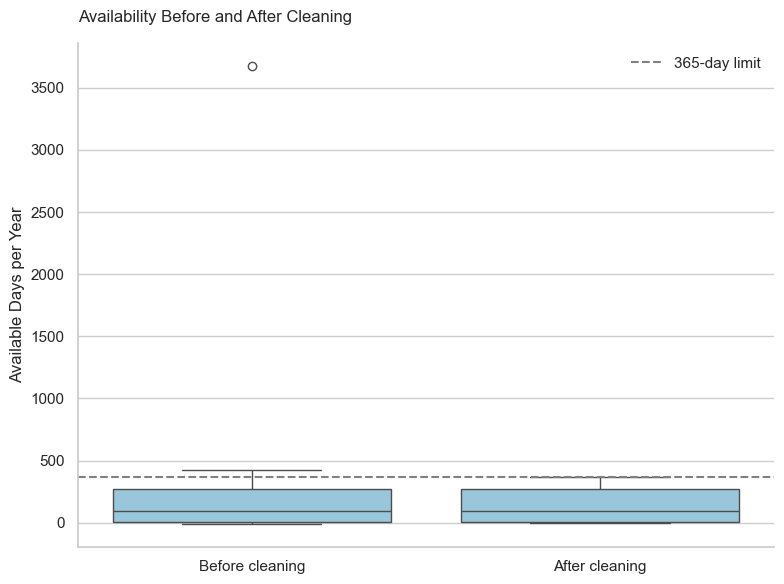

In [37]:
plot_data = pd.DataFrame({
    'Before cleaning': df_before_cleaning['availability_365'],
    'After cleaning': df['availability_365']
})

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(data=plot_data, ax=ax, color='#8ecae6', showfliers=True)

ax.set_title('Availability Before and After Cleaning', loc='left', pad=15)
ax.set_ylabel('Available Days per Year')
ax.axhline(365, color='gray', linestyle='--', label='365-day limit')
ax.legend(frameon=False)

sns.despine(ax=ax)
fig.tight_layout()
plt.show()

### Question 1 
What is the price per room and neightbourhood group? 


In [26]:
price_df = df[['price', 'room_type', 'service_fee', 'neighbourhood_group']]

In [27]:
price_analysis = price_df.groupby(['neighbourhood_group', 'room_type'])['price'].median().unstack()

In [28]:
price_analysis

room_type,entire home/apt,hotel room,private room,shared room
neighbourhood_group,,,,
Bronx,621.0,NaN,655.0,608.0
Brooklyn,626.0,832.0,624.0,659.0
Manhattan,622.0,638.5,621.0,643.0
Queens,624.0,367.5,630.0,655.0
Staten Island,666.0,NaN,581.0,680.0
Unknown,651.0,NaN,960.0,NaN


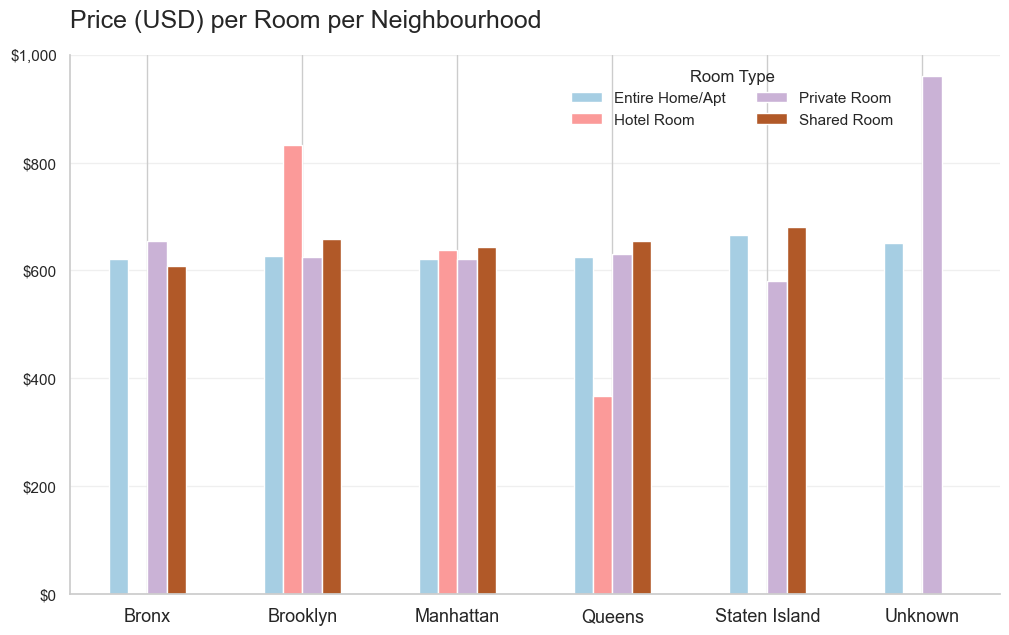

<Figure size 640x480 with 0 Axes>

In [39]:
fig, ax = plt.subplots(figsize=(12,7))

sns.set_theme(style='whitegrid')

price_analysis.plot(kind='bar',
                    ax=ax,
                    ylabel='', 
                    colormap='Paired',
                    ylim=(0, 1000))



ax.set_title('Price (USD) per Room per Neighbourhood', fontsize = 18, loc = 'left', pad = 20)

ax.set_xticklabels([label.get_text().title() for label in ax.get_xticklabels()],
                   ha = 'center')

ax.tick_params(axis='x', rotation =0, labelsize=13)

ax.set_xlabel(xlabel='')


ax.legend(title = 'Room Type',
          labels = [label.title() for label in price_analysis.columns], 
          ncol=2,
          loc='upper right',
          bbox_to_anchor = (0.90,1),
          frameon=False
          )


yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([f'${int(y):,}' for y in yticks])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout
plt.show()

plt.savefig("Room_Price_per_Neighborhood.png")




### Question 2

How is demand in brooklyn's neighborhoods? 

In [30]:
brooklyn_df = df[df['neighbourhood_group'] == 'Brooklyn']

brooklyn_stats = brooklyn_df.groupby('neighbourhood').agg(
    listing_count=('price', 'count'),
    median_price=('price', 'median'),
    median_reviews_per_month=('reviews_per_month', 'median'),
    avg_review_rate=('review_rate_number', 'mean')
).reset_index()

# Filter out neighbourhoods with too few listings to trust the stats
brooklyn_stats = brooklyn_stats[brooklyn_stats['listing_count'] >= 20]

Picking listings_count below the median count and those with monthly review above the median to narrow down neighborhoods with few listing and high monthly review  (demand proxy) 

Picking the neighborhoods with the most reviews per month 

In [31]:
candidates = brooklyn_stats[
    (brooklyn_stats['listing_count'] <= brooklyn_stats['listing_count'].median()) &
    (brooklyn_stats['median_reviews_per_month'] >= brooklyn_stats['median_reviews_per_month'].median())
]

top10 = candidates.nlargest(10, 'median_reviews_per_month').reset_index(drop=True)

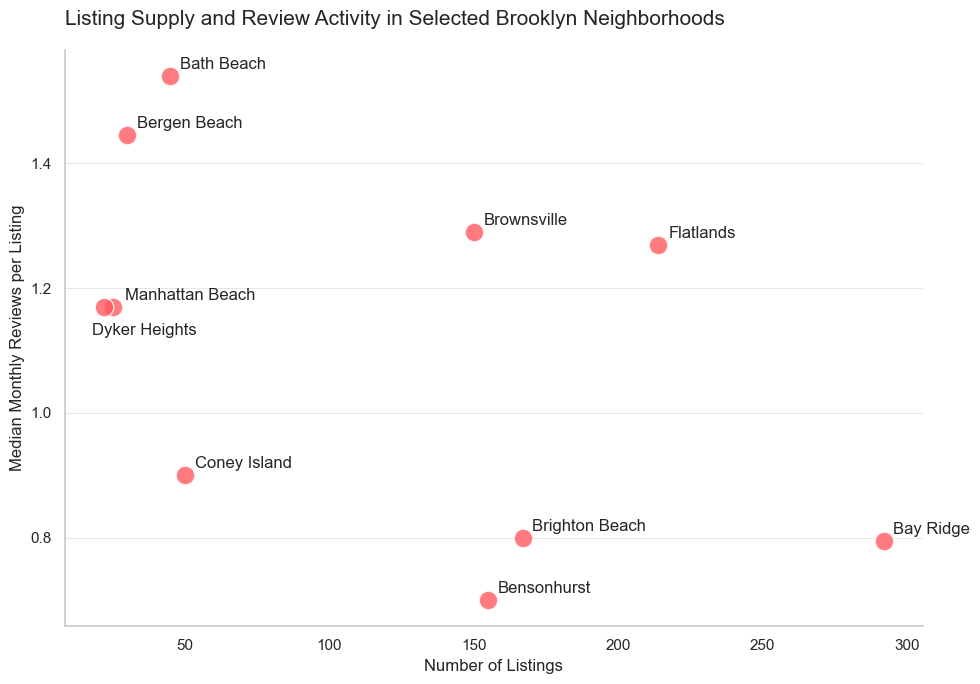

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    top10['listing_count'],
    top10['median_reviews_per_month'],
    s=180,
    color='#FF5A5F',
    edgecolor='white',
    linewidth=1,
    alpha = 0.8
)

label_offsets = {
    'manhattan beach': (15, 5),
    'dyker heights': (-15, -20)
}

for _, row in top10.iterrows():
    name = row['neighbourhood']
    dx, dy = label_offsets.get(name, (7, 5))

    ax.annotate(
        name.title(),
        (row['listing_count'], row['median_reviews_per_month']),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=12,
    )

ax.set_title(
    'Listing Supply and Review Activity in Selected Brooklyn Neighborhoods',
    loc='left',
    fontsize=15,
    pad=18
)
ax.set_xlabel('Number of Listings')
ax.set_ylabel('Median Monthly Reviews per Listing')

ax.xaxis.grid(False)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.7)
sns.despine(ax=ax)

fig.tight_layout()
plt.show()

In [33]:
top10

,neighbourhood,listing_count,median_price,median_reviews_per_month,avg_review_rate
0,bath beach,45,828.0,1.540,3.222222
1,bergen beach,30,517.0,1.445,2.833333
2,brownsville,150,684.5,1.290,3.500000
3,flatlands,214,584.0,1.270,3.168224
4,dyker heights,25,555.0,1.170,3.200000
5,manhattan beach,22,698.0,1.170,2.409091
6,coney island,50,719.0,0.900,3.080000
7,brighton beach,167,660.0,0.800,3.419162
8,bay ridge,292,610.5,0.795,3.157534
9,bensonhurst,155,569.0,0.700,3.277419


In [34]:
candidates = brooklyn_stats[brooklyn_stats['listing_count'] <= 50]

target_neighbourhoods = (
    candidates.nlargest(3, 'median_reviews_per_month')['neighbourhood']
    .tolist()
)

print(target_neighbourhoods)

['bath beach', 'bergen beach', 'dyker heights']


In [35]:
price_by_room = (
    brooklyn_df[brooklyn_df['neighbourhood'].isin(target_neighbourhoods)]
    .groupby(['neighbourhood', 'room_type'])['price']
    .median()
    .unstack()
)

print(price_by_room)

room_type      entire home/apt  private room  shared room
neighbourhood                                            
bath beach               912.5         802.0          NaN
bergen beach             550.5         517.0          NaN
dyker heights            504.0         759.0        555.0


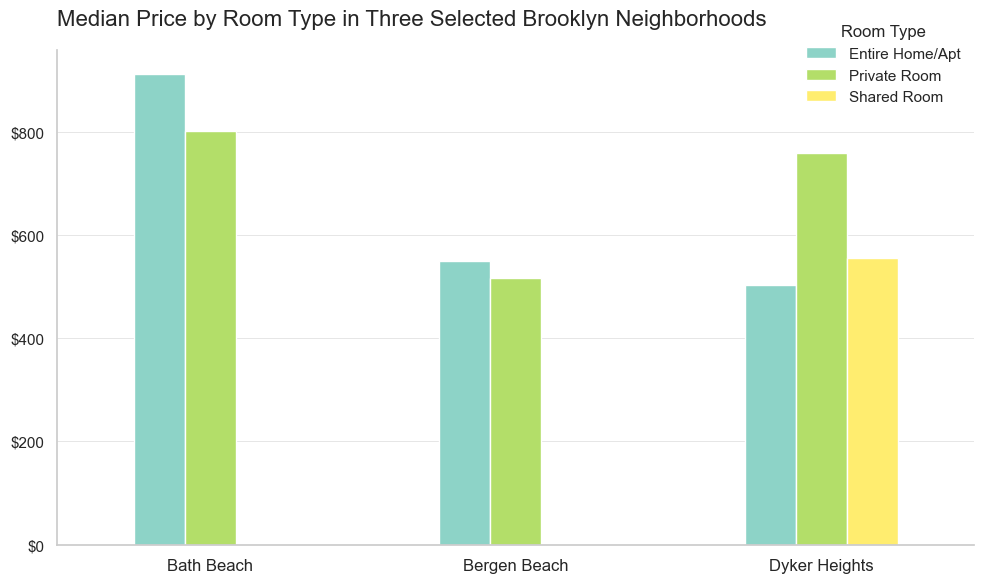

In [36]:
import matplotlib.ticker as mticker

sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(10,6))



price_by_room.plot(kind='bar', ax=ax, colormap='Set3')

ax.set_xticks(
    ax.get_xticks(), 
    labels=[name.title() for name in price_by_room.index]

)

ax.set_title(
    'Median Price by Room Type in Three Selected Brooklyn Neighborhoods',
    loc='left',
    fontsize=16,
    pad=18
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation =0, labelsize=12)

ax.yaxis.set_major_formatter(
    mticker.StrMethodFormatter('${x:,.0f}')
)

ax.xaxis.grid(False)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.7)
sns.despine(ax=ax)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles, 
    [label.title () for label in labels],
    title = 'Room Type',
    frameon=False,
    loc = 'upper right',
    bbox_to_anchor=(1, 1.08)
)


plt.tight_layout()
plt.show()
